# Exemple 4.2

Resposta temporal d'un sistema massa-molla-esmorteidor

En aquest notebook es calcula la **resposta temporal** d'un sistema mecànic equivalent format per una massa, un element esmorteidor i una rigidesa.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Dades del problema

Definim els paràmetres del sistema mecànic:

- $m$ : massa
- $c$ : coeficient d'amortiment
- $k$ : rigidesa de la molla

i la condició inicial:

- $x_0$ : desplaçament inicial

In [ ]:
m = 108   # kg, massa
c = 78    # Ns/m, amortiment
k = 2925  # N/m, rigidesa

x0 = 1e-3   # m, condició inicial de desplaçament

## Sistema equivalent

La massa equivalent inclou la contribució de la massa distribuïda:

$$
m_{eq} = \frac{1}{9} \left( m + \frac{1}{12}m) \right)
$$

i la rigdesa equivalent:

$$ k_{eq} = \frac{k}{9}$$

In [ ]:
m_eq = (m + 1/12*m)/9
c_eq = c
k_eq = k/9

## Càlcul simbòlic de la resposta temporal

A partir de la funció de transferència

$$
F(s) = \frac{x_0 m_{eq}s + c_{eq}x_0}{m_{eq}s^2 + c_{eq}s + k_{eq}}
$$

es calcula la resposta temporal utilitzant la **transformada inversa de Laplace** amb `SymPy`.

El resultat és una **expressió analítica tancada** $x(t)$.

In [ ]:
t_ = np.arange(0,1.6,0.01)

s, t = sp.symbols('s t', real=True)

F = (x0*m_eq*s + c_eq*x0)/(m_eq*s**2 + c_eq*s + k_eq)

# Transformada inversa de Laplace
f2 = sp.inverse_laplace_transform(F, s, t)

print("\nExpressió tancada:")
sp.pretty_print(f2)


Expressió tancada:
⎛         -3.0⋅t                     -3.0⋅t           ⎞     
⎝0.00075⋅ℯ      ⋅sin(4.0⋅t) + 0.001⋅ℯ      ⋅cos(4.0⋅t)⎠⋅θ(t)


## Valoració de la resposta temporal

Evaluem l'expressió simbòlica per un determinat interval de temps.

Calculem els valors inicials i final. I finalment visualitzem la respota gràficament.

In [ ]:
# Convertim l'expressió simbòlica a funció numèrica
f2_num = sp.lambdify(t, f2, 'numpy')

# Avaluació sobre el vector temporal
f_ = f2_num(t_)

In [ ]:
# teoremes valor inicial i final
initial_value = sp.limit(s*F, s, sp.oo)
final_value = sp.limit(s*F, s, 0)

print("\nValor inicial: x(t_0) = ",initial_value, " m")
print("Valor final:     x(t_f) = ",final_value, " m")


Valor inicial: x(t_0) =  1/1000  m
Valor final:     x(t_f) =  0  m


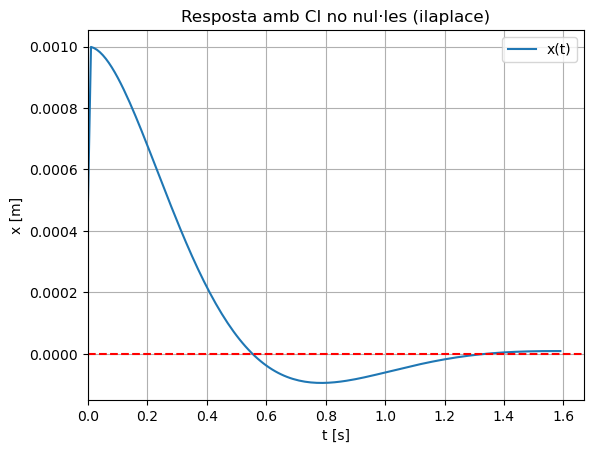

In [ ]:
fig, ax = plt.subplots()

ax.plot(t_, f_, label='x(t)')

# línia horitzontal a x = final_value
ax.axhline(float(final_value), color='r', linestyle='--')

ax.set_xlim(left=0)
ax.set_xlabel('t [s]')
ax.set_ylabel('x [m]')
ax.set_title('Resposta amb CI no nul·les (ilaplace)')

ax.grid(True)
ax.legend()

plt.show()